In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import xarray as xr

## 1. Sensitivity of the Q10 function to parameters

Bigger denominators - less sensitive to temperature. 
That's great, meaning that to make shrubs uptake more at higher temperatures, I just give them a smaller denominator. 
Set shrub = 4, tree = 6 for trial

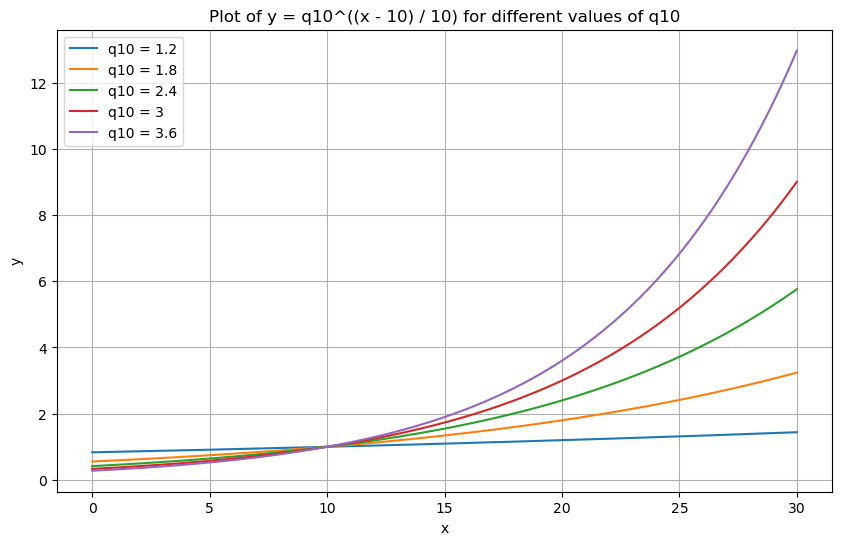

In [3]:
# Define the function with an additional parameter z
def f(x, q10, z, tbase):
    return q10 ** ((x - tbase) / z)

#
tbase = 10
z = 10 # z_vlaues = [10, 16, 20]
q10_values = [1.2, 1.8, 2.4, 3, 3.6]

# Generate x values
x = np.linspace(0, 30, 400)

# Create the plot
plt.figure(figsize=(10, 6))

# Plot for different values of z
for q10 in q10_values:
    y = f(x, q10, z, tbase)
    plt.plot(x, y, label=f'q10 = {q10}')

plt.title(f'Plot of y = q10^((x - {tbase}) / {z}) for different values of q10')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

## 2. Sensitivity of the Michaelis-Menten function to parameters

sminn_vr: gN m-3, soil mineral N

* defined by: `col_ns%sminn_vr(c,j) = col_ns%smin_nh4_vr(c,j) + col_ns%smin_no3_vr(c,j)`

sminp_vr: gP m-3, soil mineral P

* defined by: `this%sminp_vr(c,j) = this%solutionp_vr(c,j) + this%labilep_vr(c,j) + this%secondp_vr(c,j)`

This one can wait until last. As controlled by the affinity parameter, the uptake can only be uniformly higher or lower. Hence this may not be useful for temperature-dependent competitive advantages. 

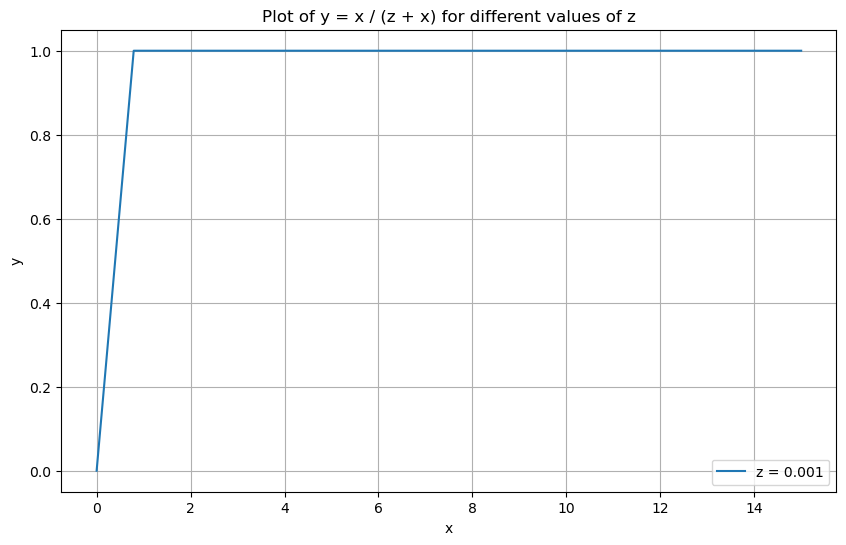

In [4]:
# Define the function with an additional parameter z
def g(x, z):
    return x / (z + x)

# Generate x values
x = np.linspace(0, 15, 20)

# Create the plot
plt.figure(figsize=(10, 6))

# Plot for different values of z
z_values = [1e-3]
for z in z_values:
    y = g(x, z)
    plt.plot(x, y**0.01, label=f'z = {z}')

plt.title('Plot of y = x / (z + x) for different values of z')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

In [5]:
y**(1e-4)

array([0.        , 0.99999987, 0.99999994, 0.99999996, 0.99999997,
       0.99999997, 0.99999998, 0.99999998, 0.99999998, 0.99999999,
       0.99999999, 0.99999999, 0.99999999, 0.99999999, 0.99999999,
       0.99999999, 0.99999999, 0.99999999, 0.99999999, 0.99999999])

## 3. Fine root biomass control

Rationale

1. fine root uptake should be proportional to root surface area (= root biomass here)

2. in reality, plants allocate more carbon to enhance fine root nutrients uptake when the root is not giving enough nutrients. This cannot be achieved through allocating more carbon for fine root growth in ELM. But, we can create the following function for nutrient uptake ($U_t$)

$$U_{t} = C_{froot, t} \cdot \tau( C_{froot, t}, FPI_{t-1} )$$

For convenience, suppose we already added a tiny value to fine root biomass so that it never hits zero ($C_{froot, t} = C_{froot, t} + \text{eps}$). Let's also denote the nutrient demand $T_t = C_{avail,t} / CN_{allometry}$

$$\tau = \frac{T_t}{C_{froot,t}} \cdot e^{-\alpha FPI_{t-1}} + \tau_0 \cdot (1 - e^{-\alpha FPI_{t-1}})$$

When nutrient is extremely limiting ($FPI \rightarrow 0$), $U_t = T_t$ - that is, plant enhances nutrients uptake (through unrepresented mechanism*) so much that the potential $U_{t}$ reaches its actual demand. 

When nutrient is extremely abundant ($FPI \rightarrow \infty$), $U_t = C_{froot,t} \cdot \tau_0$


\* This missing link will require additional modifications through carbon cost of nutrients uptake. To represent the cost of enhancing nutrients uptake, increase the MR (if we assume nutrients are mainly uptaken by mycorrhizae) or GR (less danger of running into more missing mechanisms) by an exponent $1 + \gamma e^{-\beta FPI_{t-1}}$

## 4. Stem allocation function

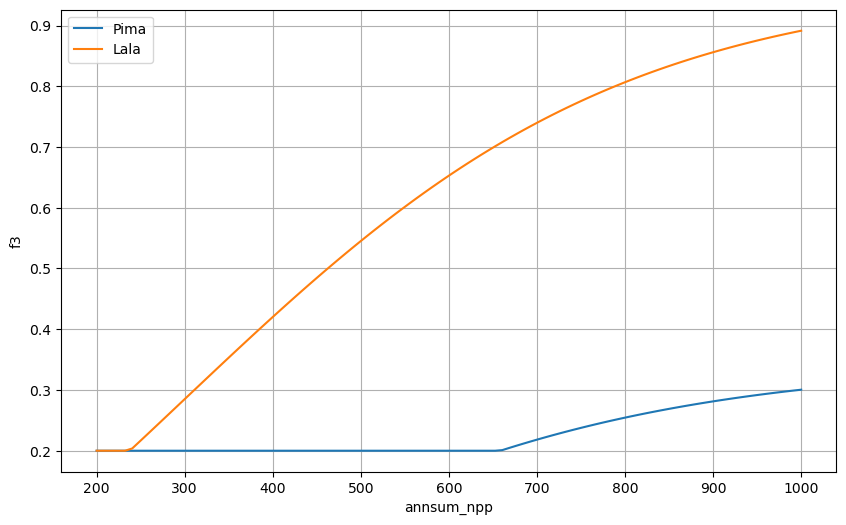

In [6]:
def f3(annsum_npp, stem_leaf):
    return np.maximum((-stem_leaf*2.7)/(1+np.exp(-0.004*(annsum_npp - 300))) - 0.4, 0.2)


# Generate x values
x = np.linspace(200, 1000, 100)

# Create the plot
plt.figure(figsize=(10, 6))

# Plot for different values of z
stem_leaf = [-0.275204284477043, -0.507394631180568]
for z, name in zip(stem_leaf,['Pima','Lala']):
    y = f3(x, z)
    plt.plot(x, y, label=name)
plt.legend()
plt.xlabel('annsum_npp')
plt.ylabel('f3')
plt.legend()
plt.grid(True)
plt.show()

## 5. Relationship between stem_root and belowground-to-aboveground NPP ratio - they are different

$$
\frac{\text{LEAF} + \text{STEM}}{\text{FROOT} + \text{CROOT}} = \frac{1 + \frac{\text{STEM}}{\text{LEAF}}}{\frac{\text{FROOT}}{\text{LEAF}} + \frac{\text{CROOT}}{\text{STEM}} \frac{\text{STEM}}{\text{LEAF}} }
$$

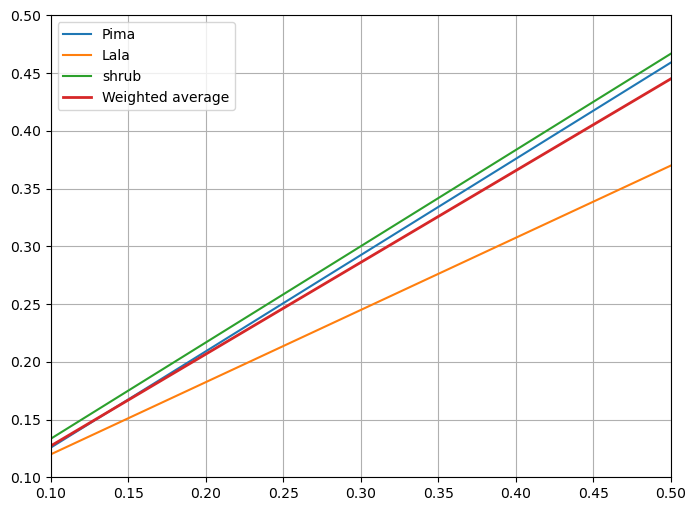

In [20]:
def bg_to_ag(froot_leaf, stem_leaf, croot_stem):
    return (froot_leaf + stem_leaf * croot_stem) / (1 + stem_leaf)

froot_leaf = np.linspace(0.1, 0.5, 20)

plt.figure(figsize = (8, 6))
plt.plot(froot_leaf, bg_to_ag(froot_leaf, 0.2, 0.254), label = 'Pima')
plt.plot(froot_leaf, bg_to_ag(froot_leaf, 0.6, 0.1529), label = 'Lala')
plt.plot(froot_leaf, bg_to_ag(froot_leaf, 0.2, 0.3), label = 'shrub')

plt.plot(froot_leaf, bg_to_ag(froot_leaf, 0.2, 0.3)*0.25/0.75 + \
         bg_to_ag(froot_leaf, 0.6, 0.1529) * 0.14/0.75 + \
         bg_to_ag(froot_leaf, 0.2, 0.254) * 0.36/0.75, label = 'Weighted average', lw = 2)

plt.legend()
plt.xlim([0.1, 0.5])
plt.ylim([0.1, 0.5])
plt.grid(True)

## 6. CNP allometry equations


$$\text{callo} = (1 + \text{grperc}) \times (1 + \text{froot\_leaf} + \text{stem\_leaf} \times (1 + \text{croot\_stem}))$$

$$\text{nallo} = \frac{1}{\text{leafcn}} + \frac{\text{froot\_leaf}}{\text{frootcn}} + \frac{\text{stem\_leaf} \times \text{flivewd} \times (1 + \text{croot\_stem})}{\text{livewdcn}} + \frac{\text{stem\_leaf} \times (1 - \text{flivewd}) \times (1 + \text{croot\_stem})}{\text{deadwdcn}}$$

$$\text{pallo} = \frac{1}{\text{leafcp}} + \frac{\text{froot\_leaf}}{\text{frootcp}} + \frac{\text{\text{stem\_leaf}} \times \text{flivewd} \times (1 + \text{croot\_stem})}{\text{livewdcp}} + \frac{\text{stem\_leaf} \times (1 - \text{flivewd}) \times (1 + \text{croot\_stem})}{\text{deadwdcp}}$$

In [2]:
hr = xr.open_dataset(os.path.join(os.environ['PROJDIR'], 'E3SM', 'inputdata', 'atm', 'datm7', 
                                  'CLM1PT_data', 'SPRUCE_data', 
                                  'clm_params_SPRUCE_20231120_spruceroot.nc_CNP'))

In [10]:
callo = (1 + hr['grperc']) * (1 + hr['froot_leaf'] + hr['stem_leaf'] * (1 + hr['croot_stem']))
nallo = 1 / hr['leafcn'] + hr['froot_leaf'] / hr['frootcn'] + hr['stem_leaf'] * hr['flivewd'] * (1 + hr['croot_stem']) / hr['livewdcn'] + hr['stem_leaf'] * (1 - hr['flivewd']) * (1 + hr['croot_stem']) / hr['deadwdcn']
pallo = 1 / hr['leafcp'] + hr['froot_leaf'] / hr['frootcp'] + hr['stem_leaf'] * hr['flivewd'] * (1 + hr['croot_stem']) / hr['livewdcp'] + hr['stem_leaf'] * (1 - hr['flivewd']) * (1 + hr['croot_stem']) / hr['deadwdcp']

print(np.around( (nallo / callo).values, 4 )[[2,3,11]])
print(np.around( (pallo / callo).values, 5 )[[2,3,11]])

[0.0225 0.0249 0.0192]
[0.00154 0.00185 0.00116]
